Load the RSA output data (with the a config that used euclidean distance) of all the subjects. Compute the mean value (e.g. mean spearman correlation that was computed to assess the similarity between the Searchlight RDMs and the model RDM) over subjects. Then plot the clusters with the highest values. 

The threshold for these values can be adjusted. The > threshold fitered data will be safed as ".nii" file. 


There are multiple plot options to show different aspects of the data. The standard is plot nr. 5. (Computes the mean, but only uses voxels where data from all subjects is available)

The output plots of plot 5 will also be saved. Mind the text-based pop-up dialog at the top of the window if png files are about to be overwritten.

In [ ]:

import os
import sys
sys.path.append(os.path.dirname(os.path.dirname(__file__)))
from configs.config2 import * # directories + constants

import re
from glob import glob
from collections import defaultdict
import warnings
import joblib
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import nibabel as nib
from nilearn import plotting
import rsatoolbox as rsa
import copy

from utils.load_cfg import load_config_instance
from utils.compile import compile_SL_rdms_files

from nilearn.image import new_img_like
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from nilearn.regions import connected_regions
from nilearn.image import math_img
import numpy as np
from nilearn.image import get_data, new_img_like
from nilearn.regions import connected_regions
from nilearn.image import threshold_img
import warnings

In [ ]:
all_subjects = ["19910703eigl", "19910823ssld", "19951227eipo", "19970302urmr", "20020123sbhp", "20020705ttbr", "19991211mrbn"]

# Functions

In [31]:
import numpy as np
import nibabel as nib
from scipy.ndimage import label


def RDMcolormapObject(direction=1):
    cs = ['blue', 'turquoise', 'gray', 'red', 'yellow'] if direction else ['yellow', 'red', 'gray', 'turquoise', 'blue']
    return mcolors.LinearSegmentedColormap.from_list("", cs)

def plot_brainSlices(plot_img, cmap, title='', threshold = 1e-6):
 
    fig = plt.figure(figsize=(12, 3))
    plotting.plot_stat_map(
        plot_img, 
        colorbar=True, 
        threshold=threshold,
        cut_coords=[-30, -20, 0, 20, 40, 60],
        display_mode='z', 
        draw_cross=False, 
        figure=fig,
        title=title, 
        cmap=cmap,
        black_bg=False, 
        annotate=False
    )
    plt.show()
    return plt


cmap = RDMcolormapObject()


def save_plot_dialogue(plt, plot_fileName):
    if os.path.isfile(plot_fileName): # open dialogue if file already exists
        response = input(f"\npng File already exists. Do you still want to save the plot as:\n  {plot_fileName}?\n\nType \n[yes] to save, \n[adjust] to change filename, or \n[no] to skip: ").strip().lower()

        if response == "yes":
            plt.savefig(plot_fileName)
            print(f"Plot saved as {plot_fileName}")
        elif response == "adjust":
            new_name = input("Enter new filename (with .png extension): ").strip()
            if not new_name.lower().endswith(".png"):
                new_name += ".png"
            new_path = os.path.join(os.path.dirname(plot_fileName), new_name)
            plt.savefig(new_path)
            print(f"Plot saved as {new_path}")
        elif response == "no":
            print("Skipped saving the plot.")
        else:
            print("Invalid response. Skipped saving.")

    else: # save fig if file doesn't already exist
        plt.savefig(plot_fileName)
        print(f"Plot saved as {plot_fileName}")

def my_plots(cfg, config_class_name, mask, RDM_brain_all, RDM_brain_mean_nan, threshold, thres_string, plotList = [5], save = False):
    
    zero_count_3d = np.sum(RDM_brain_all == 0, axis=-1)
    # find voxels where we have no zeros
    no_zeros_bool = zero_count_3d == 0
    no_zeros_3d = np.zeros(zero_count_3d.shape)
    no_zeros_3d[zero_count_3d == 0] = 1

    RDM_brain_mean = np.mean(RDM_brain_all, axis=-1)
    RDM_brain_nan_mean_noZeros = np.zeros(RDM_brain_mean_nan.shape)
    RDM_brain_nan_mean_noZeros[no_zeros_bool] = RDM_brain_mean_nan[no_zeros_bool]

    max1zero = zero_count_3d < 2
    RDM_brain_nan_mean_1zero = np.zeros(RDM_brain_mean_nan.shape)
    RDM_brain_nan_mean_1zero[max1zero] = RDM_brain_mean_nan[max1zero]
    
    max2zero = zero_count_3d < 3
    RDM_brain_nan_mean_2zero = np.zeros(RDM_brain_mean_nan.shape)
    RDM_brain_nan_mean_2zero[max2zero] = RDM_brain_mean_nan[max2zero]
    
    outDir = '/home/reabt/experiments/ncc/MRI/data/rsa'
    fileSuffix = f'_{cfg.modelType}__{config_class_name}__thres_{thres_string}__{RDM_brain_all.shape[3]}_subj.nii'

    plot_fileName = os.path.join('/home/reabt/experiments/ncc/MRI/code/outputs', f'{cfg.modelType}__{RDM_brain_all.shape[3]}_subj_mean__thr{thres_string}.png')
    # plot_fileName = os.path.join('/home/reabt/experiments/ncc/MRI/code/outputs', 'dialogtest.png')


    if 1 in plotList:
        #%% 1) --- plot zeros
        count_zeros_img = new_img_like(mask, zero_count_3d.astype(np.int16))
        plt = plot_brainSlices(count_zeros_img, 
                         cmap, 
                         title=f'{cfg.modelType} (config {config_class_name[-2 :]}): zeros across subjects')

    if 2 in plotList:
        #%% 2) --- plot no zeros
        no_zeros_img = new_img_like(mask, no_zeros_3d.astype(np.int16))
        plt = plot_brainSlices(no_zeros_img, 
                         cmap, title=f'{cfg.modelType} (config {config_class_name[-2 :]}): no zeros')
        
    if 3 in plotList:
        #%% 3) --- plot mean over subjects
        mean_img = new_img_like(mask, RDM_brain_mean)
        plt = plot_brainSlices(mean_img, 
                         cmap = 'viridis', 
                         title=f'{cfg.modelType} (config {config_class_name[-2 :]}): mean results over {RDM_brain_all.shape[3]} subjects', 
                         threshold = threshold)

    if 4 in plotList:
        #%% 4) --- plot mean over subjects but omit zeros (NaN)
        mean_nan_img = new_img_like(mask, RDM_brain_mean_nan)
        plt = plot_brainSlices(mean_nan_img, 
                         cmap = 'inferno', 
                         title=f'{cfg.modelType} (config {config_class_name[-2 :]}): mean results over {RDM_brain_all.shape[3]} subjects without zeros (NaN)', 
                         threshold = threshold)

    if 5 in plotList:
        #%% 5) --- plot mean over subjects. Only use voxel where no subject has zeros
        mean_nan_noZeros_img = new_img_like(mask, RDM_brain_nan_mean_noZeros)
        plt = plot_brainSlices(mean_nan_noZeros_img, 
                         cmap = 'inferno', 
                         title=f'{cfg.modelType} (config {config_class_name[-2 :]}): SL-radius = {cfg.SLradius}, mean results over {RDM_brain_all.shape[3]} subjects with no-zeros mask, threshold: {thres_string} %', 
                         threshold = threshold)
        if save:
            save_plot_dialogue(plt, plot_fileName)

            threshold_value_img = threshold_img(mean_nan_noZeros_img, 
                                                threshold=threshold, 
                                                copy=True, # otherwise the input variable will also be changed!
                                                copy_header=True)
            fileprefix = 'mean_nan_noZeros'
            outFileName = os.path.join(outDir, f'{fileprefix}_{fileSuffix}')
            nib.save(threshold_value_img, outFileName)
            print(f'saved nifti image as {outFileName}')
        else: 
            print(' Output nii file and output plot were NOT saved! Set "save = True" to save the files the next time.')

    if 6 in plotList:
        #%% 6) --- plot mean over subjects. Only use voxel where max 1 subj has zero
        mean_nan_1zero_img = new_img_like(mask, RDM_brain_nan_mean_1zero)
        plt = plot_brainSlices(mean_nan_1zero_img, 
                         cmap = 'inferno', 
                         title=f'{cfg.modelType} (config {config_class_name[-2 :]}): mean results over {RDM_brain_all.shape[3]} subjects without zeros (NaN) and 1-zero  mask', 
                         threshold = threshold)

    if 7 in plotList:
        #%% 7) --- plot mean over subjects. Only use voxel where max 2 subj has zero
        mean_nan_2zero_img = new_img_like(mask, RDM_brain_nan_mean_2zero)
        plot_brainSlices(mean_nan_2zero_img, 
                         cmap = 'inferno', 
                         title=f'{cfg.modelType} (config {config_class_name[-2 :]}): mean results over {RDM_brain_all.shape[3]} subjects without zeros (NaN) and 2-zero  mask', 
                         threshold = threshold)


def plot_mean_results(all_subjects, config_class_name, thres_type = 'percentage', thres= 95, show_summary = False, plotList = [5], save = False):
    # load data
   
    RDM_brain_list = []
    for subjectID in all_subjects:
        cfg = load_config_instance(config_class_name, subjectID)
        outFiles = cfg.get_outFile_names()
        RDM_brain = joblib.load(outFiles['RDM_brain'])
        RDM_brain_list.append(RDM_brain)

    if show_summary:
        cfg.print_summary()
    
    mask = nib.load(cfg.maskFile)
    # Stack along the fourth dimension (axis=-1)
    RDM_brain_all = np.stack(RDM_brain_list, axis=-1)

    RDM_brain_mean = np.mean(RDM_brain_all, axis=-1)
    mean_mask_img = nib.Nifti1Image(RDM_brain_mean.astype(np.int16), mask.affine)
    # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    # compute the mean again but set zeros to NaNs first and omit them
    RDM_brain_all_nan = copy.deepcopy(RDM_brain_all)
    RDM_brain_all_nan[RDM_brain_all_nan == 0] = np.nan
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        RDM_brain_mean_nan = np.nanmean(RDM_brain_all_nan, axis=-1)
    try:
        if thres_type == 'percentage':
            threshold = np.nanpercentile(RDM_brain_mean_nan, thres)
            thres_string = str(thres)
        elif thres_type == 'fixed':
            threshold = thres
            thres_string = f'fix{str(thres).replace('.', '_')}'
    except:
        print('More info needed: Do you want to set a fixed threshold or compute it from the data?')

    print(f'threshold: {threshold}')
    my_plots(cfg, config_class_name, mask, RDM_brain_all, RDM_brain_mean_nan, threshold, thres_string, plotList, save)


# first 4 subjects

threshold: 0.29156052809718147


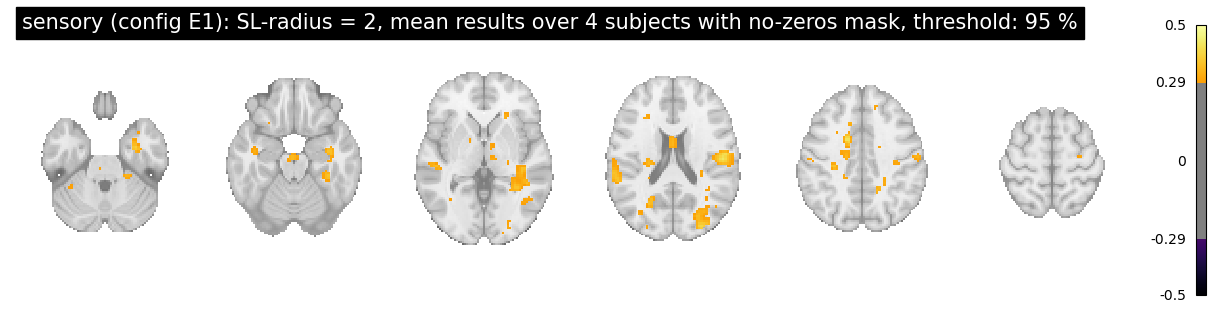

saved image as /home/reabt/experiments/ncc/MRI/data/rsa/mean_nan_noZeros__sensory__SensoryConfig_E1__thres_95__4_subj.nii
threshold: 0.38442922092048576


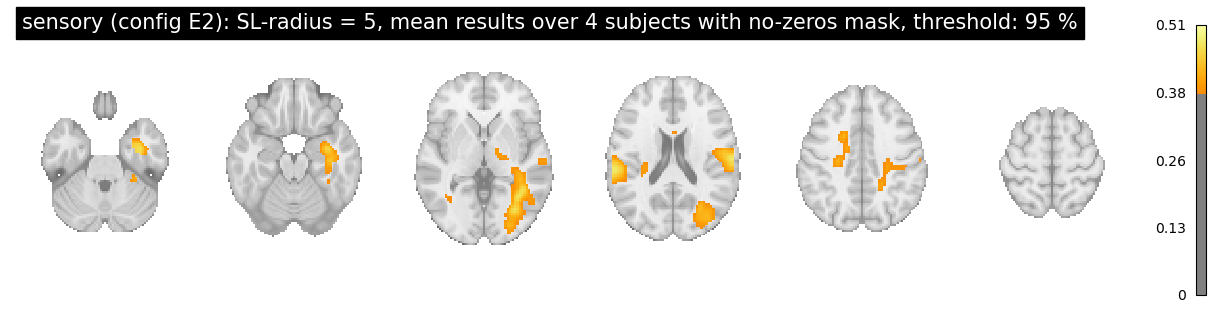

saved image as /home/reabt/experiments/ncc/MRI/data/rsa/mean_nan_noZeros__sensory__SensoryConfig_E2__thres_95__4_subj.nii
threshold: 0.049888074080773954


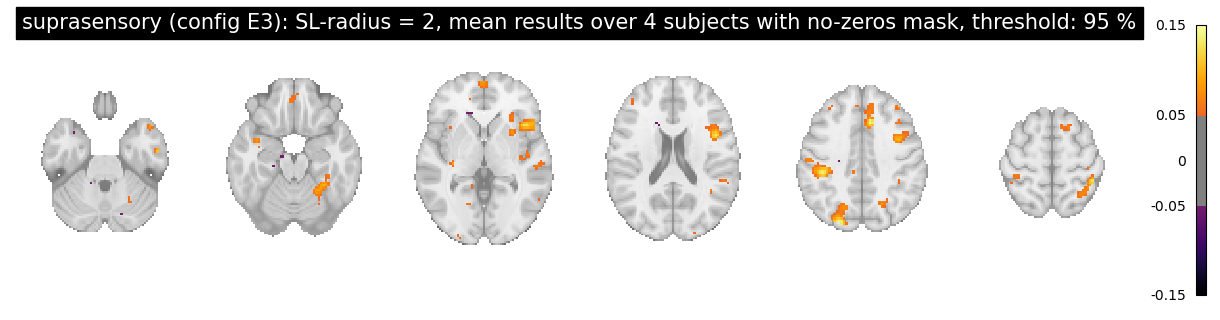

saved image as /home/reabt/experiments/ncc/MRI/data/rsa/mean_nan_noZeros__suprasensory__SensoryConfig_E3__thres_95__4_subj.nii
threshold: 0.04476726355697189


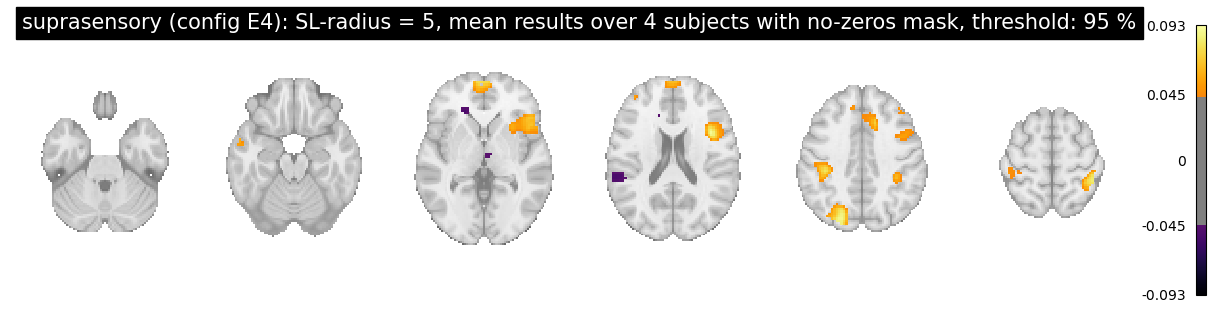

saved image as /home/reabt/experiments/ncc/MRI/data/rsa/mean_nan_noZeros__suprasensory__SensoryConfig_E4__thres_95__4_subj.nii


In [3]:
all_subjects = ["19910823ssld", "19970302urmr", "20020705ttbr", "19991211mrbn"]

config_class_name = 'SensoryConfig_E1'
plot_mean_results(all_subjects, config_class_name, thres_type='percentage', thres=95, save=True)

config_class_name = 'SensoryConfig_E2'
plot_mean_results(all_subjects, config_class_name, thres_type='percentage', thres=95, save=True)

config_class_name = 'SensoryConfig_E3'
plot_mean_results(all_subjects, config_class_name, thres_type='percentage', thres=95, save=True)

config_class_name = 'SensoryConfig_E4'
plot_mean_results(all_subjects, config_class_name, thres_type='percentage', thres=95, save=True)

threshold: 0.2620997473429477


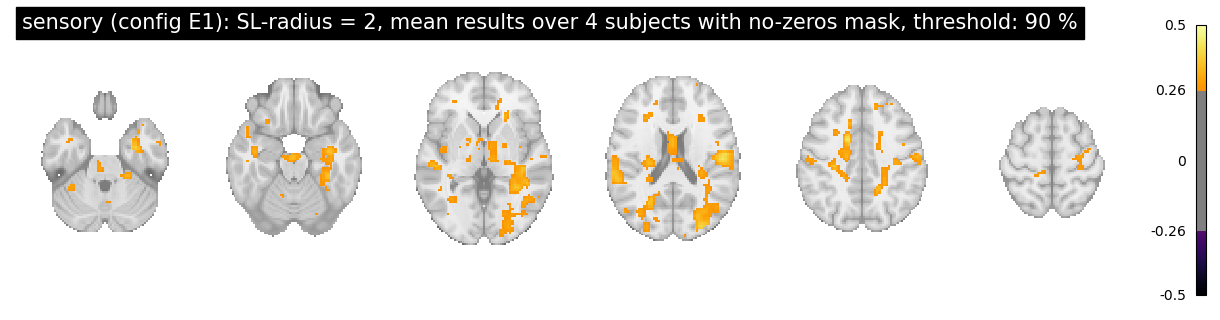

saved image as /home/reabt/experiments/ncc/MRI/data/rsa/mean_nan_noZeros__sensory__SensoryConfig_E1__thres_90__4_subj.nii
threshold: 0.35668762723290537


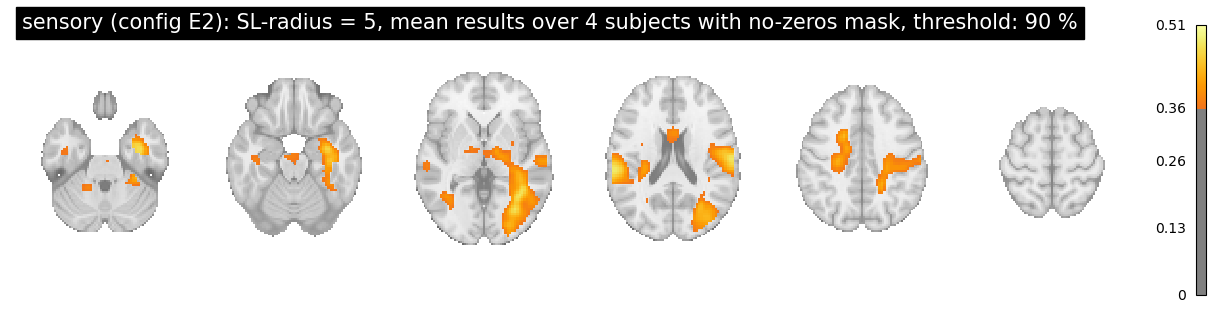

saved image as /home/reabt/experiments/ncc/MRI/data/rsa/mean_nan_noZeros__sensory__SensoryConfig_E2__thres_90__4_subj.nii
threshold: 0.035299453877408946


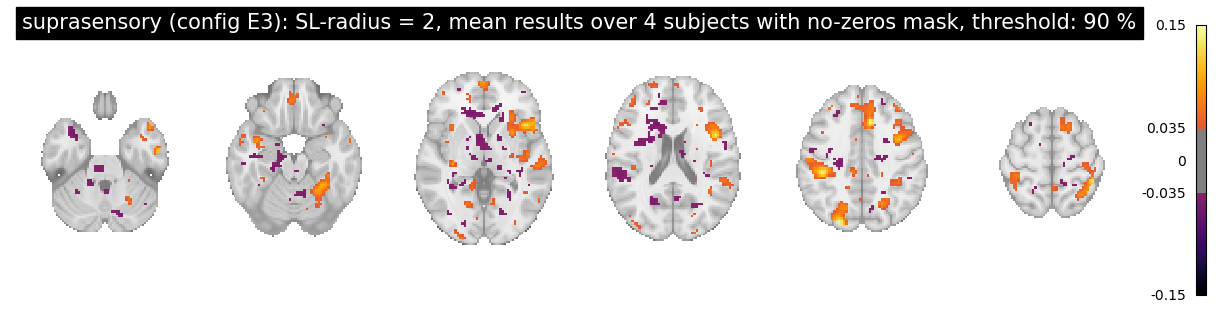

saved image as /home/reabt/experiments/ncc/MRI/data/rsa/mean_nan_noZeros__suprasensory__SensoryConfig_E3__thres_90__4_subj.nii
threshold: 0.03161247030027145


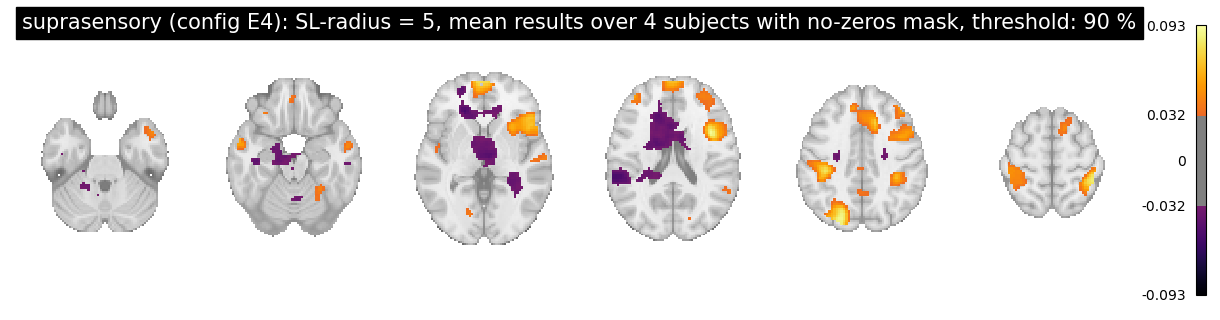

saved image as /home/reabt/experiments/ncc/MRI/data/rsa/mean_nan_noZeros__suprasensory__SensoryConfig_E4__thres_90__4_subj.nii


In [4]:
all_subjects = ["19910823ssld", "19970302urmr", "20020705ttbr", "19991211mrbn"]

config_class_name = 'SensoryConfig_E1'
plot_mean_results(all_subjects, config_class_name, thres_type='percentage', thres=90, save=True)

config_class_name = 'SensoryConfig_E2'
plot_mean_results(all_subjects, config_class_name, thres_type='percentage', thres=90, save=True)

config_class_name = 'SensoryConfig_E3'
plot_mean_results(all_subjects, config_class_name, thres_type='percentage', thres=90, save=True)

config_class_name = 'SensoryConfig_E4'
plot_mean_results(all_subjects, config_class_name, thres_type='percentage', thres=90, save=True)

### Jetzt nochmal mit fixed threshold von 0.1

In [ ]:
config_class_name = 'SensoryConfig_E1'
plot_mean_results(all_subjects, config_class_name, thres_type = 'fixed', thres= 0.1)

config_class_name = 'SensoryConfig_E2'
plot_mean_results(all_subjects, config_class_name, thres_type = 'fixed', thres= 0.1)

config_class_name = 'SensoryConfig_E3'
plot_mean_results(all_subjects, config_class_name, thres_type = 'fixed', thres= 0.1)

config_class_name = 'SensoryConfig_E4'
plot_mean_results(all_subjects, config_class_name, thres_type = 'fixed', thres= 0.1)

# einzelne subjects plotten

In [ ]:

config_class_name = 'SensoryConfig_E4'
thres= 99

# load data
all_subjects = ["19910823ssld", "19970302urmr", "20020705ttbr", "19991211mrbn"]

RDM_brain_list = []

for subjectID in all_subjects:
    cfg = load_config_instance(config_class_name, subjectID)

    mask = nib.load(cfg.maskFile)
    outFiles = cfg.get_outFile_names()
    RDM_brain = joblib.load(outFiles['RDM_brain'])

    new_img = new_img_like(mask, RDM_brain)
    threshold = np.percentile(RDM_brain, thres)
    plot_brainSlices(new_img, cmap = 'viridis', title=f'config{config_class_name} - subject {subjectID}', threshold = threshold)


# mit den neuen Subjects (=6)

threshold: 0.41453891120713027


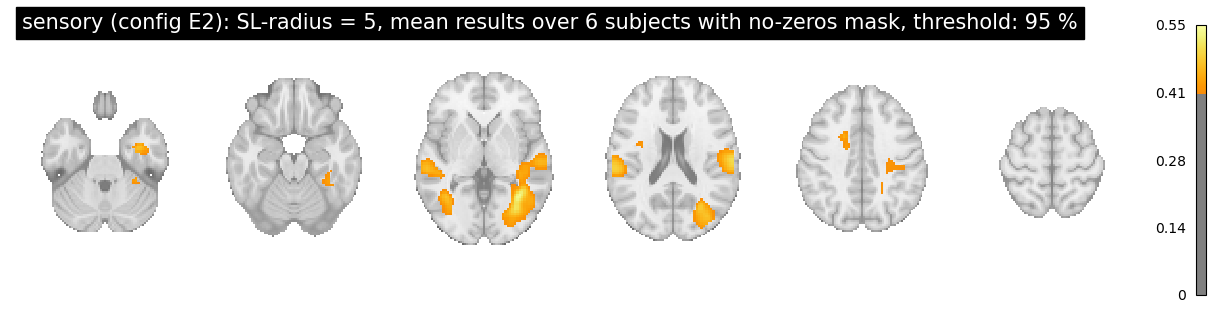

saved image as /home/reabt/experiments/ncc/MRI/data/rsa/mean_nan_noZeros__sensory__SensoryConfig_E2__thres_95__6_subj.nii
threshold: 0.04714180236282381


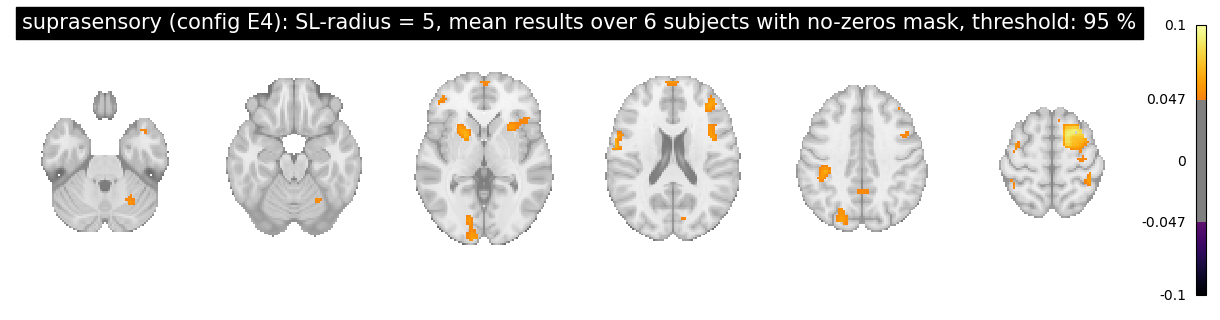

saved image as /home/reabt/experiments/ncc/MRI/data/rsa/mean_nan_noZeros__suprasensory__SensoryConfig_E4__thres_95__6_subj.nii


In [5]:
all_subjects = ["19910823ssld", "19951227eipo", "19970302urmr", "20020123sbhp", "20020705ttbr", "19991211mrbn"]

config_class_name = 'SensoryConfig_E2'
plot_mean_results(all_subjects, config_class_name, thres_type = 'percentage', thres= 95, save=True)

config_class_name = 'SensoryConfig_E4'
plot_mean_results(all_subjects, config_class_name, thres_type = 'percentage', thres= 95, save=True)

threshold: 0.37998459274579627


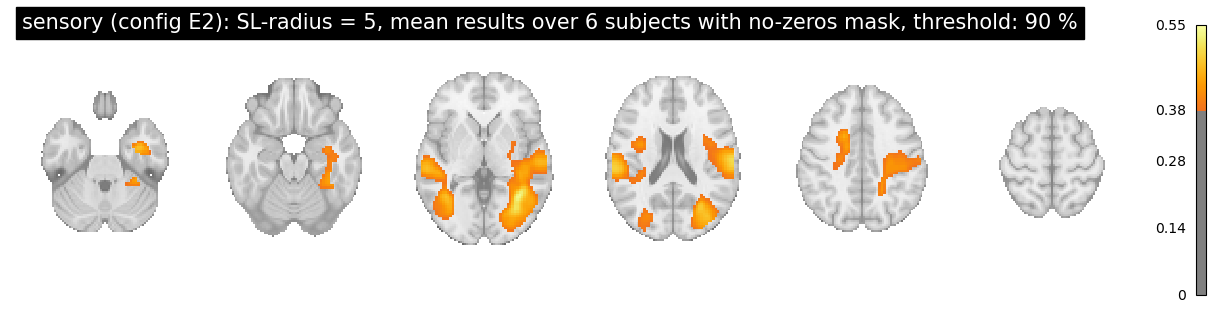

saved image as /home/reabt/experiments/ncc/MRI/data/rsa/mean_nan_noZeros__sensory__SensoryConfig_E2__thres_90__6_subj.nii
threshold: 0.03644499815754837


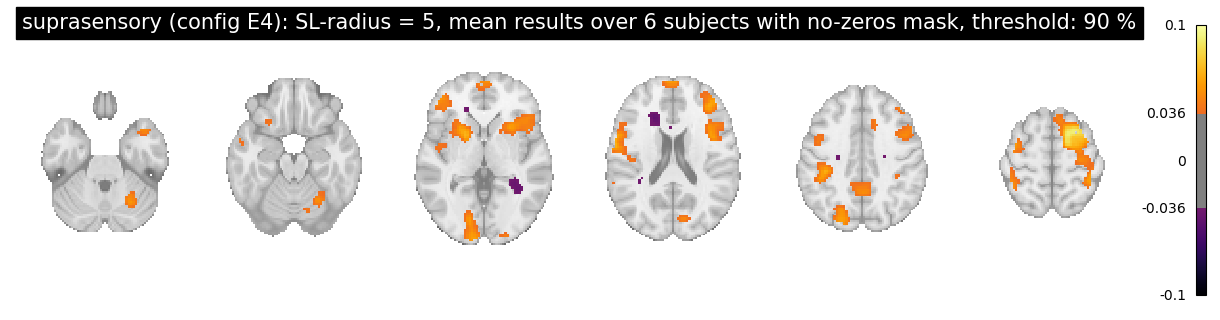

saved image as /home/reabt/experiments/ncc/MRI/data/rsa/mean_nan_noZeros__suprasensory__SensoryConfig_E4__thres_90__6_subj.nii


In [6]:
all_subjects = ["19910823ssld", "19951227eipo", "19970302urmr", "20020123sbhp", "20020705ttbr", "19991211mrbn"]

config_class_name = 'SensoryConfig_E2'
plot_mean_results(all_subjects, config_class_name, thres_type = 'percentage', thres= 90, save=True)

config_class_name = 'SensoryConfig_E4'
plot_mean_results(all_subjects, config_class_name, thres_type = 'percentage', thres= 90, save=True)

In [ ]:
all_subjects = ["19910823ssld", "19951227eipo", "19970302urmr", "20020123sbhp", "20020705ttbr", "19991211mrbn"]

config_class_name = 'SensoryConfig_E2'
plot_mean_results(all_subjects, config_class_name, thres_type = 'percentage', thres= 90, save=True)

config_class_name = 'SensoryConfig_E4'
plot_mean_results(all_subjects, config_class_name, thres_type = 'percentage', thres= 90, save=True)


7 subjects

threshold: 0.37623490140497495


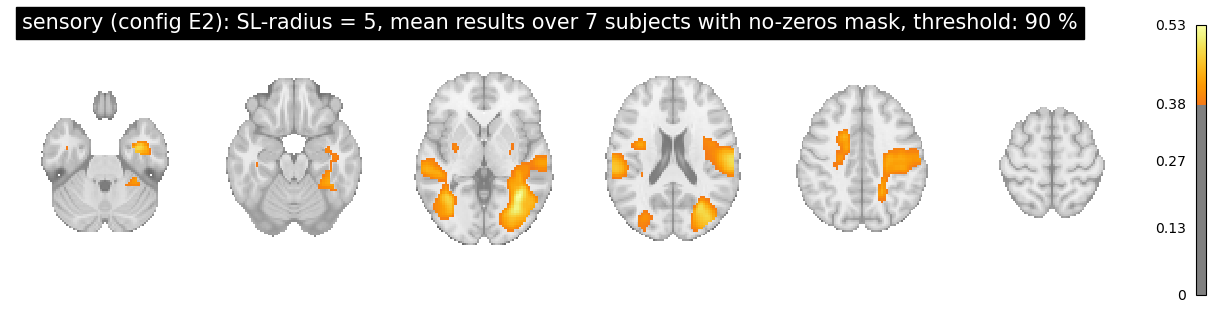

Plot saved as /home/reabt/experiments/ncc/MRI/code/outputs/sensory__7_subj_mean__thr90.png
saved nifti image as /home/reabt/experiments/ncc/MRI/data/rsa/mean_nan_noZeros__sensory__SensoryConfig_E2__thres_90__7_subj.nii
threshold: 0.41035949208546657


<Figure size 640x480 with 0 Axes>

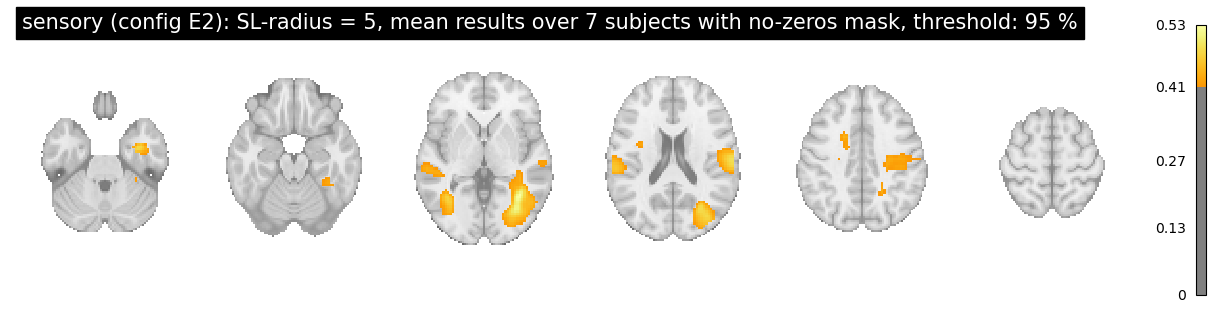

Plot saved as /home/reabt/experiments/ncc/MRI/code/outputs/sensory__7_subj_mean__thr95.png
saved nifti image as /home/reabt/experiments/ncc/MRI/data/rsa/mean_nan_noZeros__sensory__SensoryConfig_E2__thres_95__7_subj.nii


<Figure size 640x480 with 0 Axes>

In [34]:
all_subjects = ["19910703eigl", "19910823ssld", "19951227eipo", "19970302urmr", "20020123sbhp", "20020705ttbr", "19991211mrbn"]

config_class_name = 'SensoryConfig_E2'
plot_mean_results(all_subjects, config_class_name, thres_type = 'percentage', thres= 90, save=True)

config_class_name = 'SensoryConfig_E2'
plot_mean_results(all_subjects, config_class_name, thres_type = 'percentage', thres= 95, save=True)


threshold: 0.04298425772937052


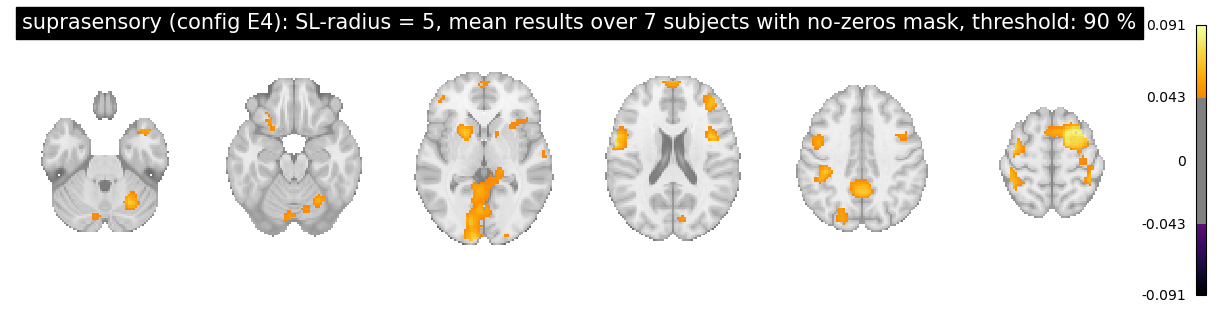

Plot saved as /home/reabt/experiments/ncc/MRI/code/outputs/suprasensory__7_subj_mean__thr90.png
saved nifti image as /home/reabt/experiments/ncc/MRI/data/rsa/mean_nan_noZeros__suprasensory__SensoryConfig_E4__thres_90__7_subj.nii
threshold: 0.053798425586390884


<Figure size 640x480 with 0 Axes>

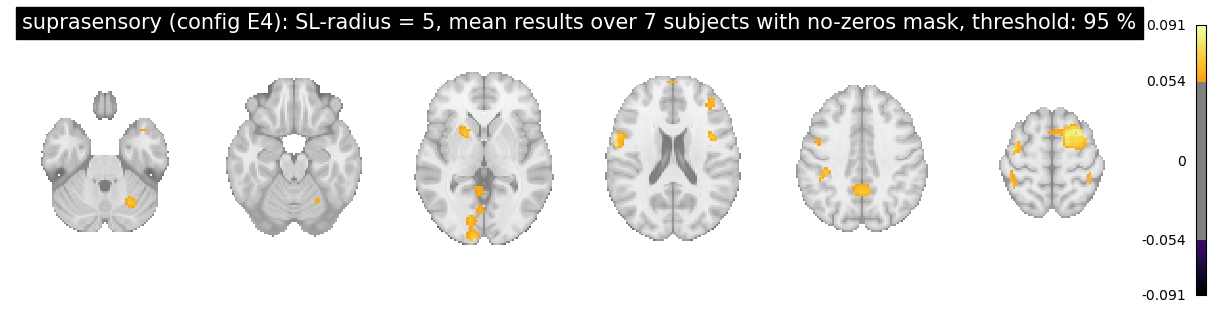

Plot saved as /home/reabt/experiments/ncc/MRI/code/outputs/suprasensory__7_subj_mean__thr95.png
saved nifti image as /home/reabt/experiments/ncc/MRI/data/rsa/mean_nan_noZeros__suprasensory__SensoryConfig_E4__thres_95__7_subj.nii


<Figure size 640x480 with 0 Axes>

In [33]:

config_class_name = 'SensoryConfig_E4'
plot_mean_results(all_subjects, config_class_name, thres_type = 'percentage', thres= 90, save=True)

config_class_name = 'SensoryConfig_E4'
plot_mean_results(all_subjects, config_class_name, thres_type = 'percentage', thres= 95, save=True)
